# Plasma-frequency extraction for plasmon_v3 test structures

This notebook analyzes the room-temperature resistance measurements for the available **plasmon_v3** structures:

1. **m1/4 — thin-JJ SQUID**, using measured SEM dimensions for the right and left junctions
2. **m2/4 — wide-JJ SQUID**, using measured SEM dimensions for the right and left junctions
3. **m3/4 — thin chain**, `N_JJ = 50`, using measured SEM dimensions and microscope light **on/off** datasets

**m4/4 is unavailable and is not included in the resistance/plasma-frequency analysis.** Its large-chain SEM measurements are retained as a geometry reference.

For the chain datasets, a net chain resistance threshold of **20 kΩ** is applied after subtraction of the series resistor. Values below this threshold are treated as shorted chains. Every readable point above the threshold is retained; no MAD/outlier filtering is applied to m3/4.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Tuple, Iterable
import scipy.constants as const

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 120)

# ============================================================
# Constants
# ============================================================
e = const.e
h = const.h
pi = np.pi
R_Q = h / (4 * e**2)      # superconducting resistance quantum for Cooper pairs [Ohm]

# Existing wp_calc notebook used Delta_Al ≈ 0.163 meV.
Delta_Al_J = 0.163e-3 * e

# Junction capacitance density. Replace if you have a fab-specific calibration.
C_J_density_F_per_um2 = 45e-15

print(f"R_Q = {R_Q:.2f} Ohm")
print(f"Delta_Al/h = {Delta_Al_J/h/1e9:.2f} GHz")

R_Q = 6453.20 Ohm
Delta_Al/h = 39.41 GHz


## 1. Inputs and selection knobs

The resistance tables below are the measured values **before** subtracting the series resistor `R_seq`.

For m3/4, the light-on and light-off measurements are kept as separate datasets so their extracted resistance and plasma-frequency distributions can be compared directly.

`R_SELECTION["mad_z_thresh"]` controls robust outlier filtering. The final statistics are anchored to the lowest available series-resistor table for each dataset.


In [2]:
# ============================================================
# Resistance-selection knobs
# ============================================================
R_SELECTION = {
    "mad_z_thresh": 3.5,
    "min_net_R_ohm": 1.0,
    "chain_min_net_R_ohm": 20e3,  # shorted-chain rejection threshold after R_seq subtraction
    "strategy": "lowest_rseq_trusted_sites",
    "window_quantiles": (0.16, 0.84),
}

# ============================================================
# SEM geometries
# All dimensions are stored in micrometres. Values supplied in nm
# are converted by multiplying by 1e-3.
# ============================================================
SEM_GEOMETRIES = {
    # Large chain (m4/4 geometry reference; structure unavailable electrically).
    # Four measured alternating-island junctions, all with 2.832 um long dimension.
    "large_chain": {
        "alternating_junctions": [
            (2.832, 248.7e-3),
            (2.832, 244.3e-3),
            (2.832, 253.1e-3),
            (2.832, 231.3e-3),
        ],
    },

    # Thin chain m3/4: four SEM measurements across the alternating islands.
    "thin_chain": {
        "alternating_junctions": [
            (1.041, 242.5e-3),
            (1.041, 281.6e-3),
            (1.041, 254.3e-3),
            (1.041, 293.4e-3),
        ],
    },

    # Wide SQUID m2/4: two SEM repeats for each physical junction.
    "wide_squid": {
        "right": [(2.747, 259.1e-3), (2.734, 258.6e-3)],
        "left":  [(2.896, 232.3e-3), (2.899, 237.9e-3)],
    },

    # Thin SQUID m1/4: two SEM repeats for each physical junction.
    "thin_squid": {
        "right": [(1.015, 329.0e-3), (1.013, 334.0e-3)],
        "left":  [(1.078, 289.6e-3), (1.078, 317.2e-3)],
    },
}

# ============================================================
# Resistance data transcribed from plasmon_v3 notebook pages 81–82
# All numerical values are in kOhm and include R_seq.
# OL = open / crossed-out / unavailable / unreadable.
# ============================================================

# m1/4 — thin-JJ SQUID, R_seq = 1.007 kOhm
# Full 6x4 table from the first close-up image.
m1_4_thin_squid_Rseq_1p007k = [
    ["OL", 1.502, 1.486, 1.493],
    [1.542, 1.525, 1.526, 1.527],
    [1.541, 1.488, 1.480, 1.479],
    [1.635, 1.542, 1.502, 1.488],
    [1.484, 1.550, 1.479, 1.500],
    [1.486, 1.524, 1.492, 1.538],
]

# m2/4 — wide-JJ SQUID, R_seq = 1.007 kOhm
# Full 6x4 table from the second close-up image.
m2_4_wide_squid_Rseq_1p007k = [
    [1.239, 1.343, 1.198, 1.216],
    [1.283, 1.216, 1.196, 1.195],
    [1.202, 1.210, 1.203, 1.197],
    [1.259, 1.200, 1.200, 1.203],
    [1.199, 1.200, 1.198, 1.203],
    [1.196, 1.208, 1.199, 1.206],
]

# m3/4 — thin chain, LIGHT ON
# High-range measurement: R_seq = 100.2 kOhm
m3_4_chain_light_on_Rseq_100p2k = [
    [132.0, 138.7, 124.9, 270.6],
    [160.0, 179.4, 125.3, 132.8],
    [237.4, 103.7, 128.4, "OL"],
    [108.4, 113.7, 106.1, "OL"],
    [102.5, 104.5, 101.9, "OL"],
    [106.0, 104.0, 107.8, "OL"],
]

# Lower-range measurement: R_seq = 10.00 kOhm
m3_4_chain_light_on_Rseq_10k = [
    [47.38, 48.97, 34.95, "OL"],
    ["OL", "OL", 35.46, 43.07],
    ["OL", 13.59, 38.32, 12.38],
    [18.34, 23.65, 16.01, 11.63],
    [12.40, 11.39, 11.76, "OL"],
    [15.90, 15.92, 17.73, "OL"],
]

# m3/4 — thin chain, LIGHT OFF
# High-range measurement: R_seq = 100.2 kOhm
m3_4_chain_light_off_Rseq_100p2k = [
    [140.6, 142.0, 126.3, "OL"],
    [127.7, 149.0, 126.9, 135.1],
    ["OL", "OL", 130.3, "OL"],
    [108.7, 114.3, 106.3, "OL"],
    [102.6, 101.6, 101.9, "OL"],
    [106.2, 104.1, 108.0, "OL"],
]

# Lower-range measurement: R_seq = 10.00 kOhm
m3_4_chain_light_off_Rseq_10k = [
    [50.55, 51.93, 36.20, "OL"],
    ["OL", "OL", 36.83, 44.98],
    ["OL", 13.62, 40.15, 12.39],
    [18.55, 24.17, 16.10, 11.63],
    [12.42, 11.39, 11.77, "OL"],
    [16.02, 13.96, 17.89, "OL"],
]

# ============================================================
# Analysis configuration
# ============================================================
TEST_STRUCTURES = {
    "m1_4_thin_squid": {
        "kind": "asymmetric_squid",
        "description": "m1/4 SQUID with thin JJs; measured SEM geometry.",
        "junction_count": 2,
        "resistance_unit": "kOhm",
        "geometry": {"chainW_design_um": 1.0, "SQUIDd_design": 0.032, "geometry_source": "SEM"},
        "sem": SEM_GEOMETRIES["thin_squid"],
        "resistance_tables_by_Rseq": {1.007: m1_4_thin_squid_Rseq_1p007k},
    },

    "m2_4_wide_squid": {
        "kind": "asymmetric_squid",
        "description": "m2/4 SQUID with wide JJs; measured SEM geometry.",
        "junction_count": 2,
        "resistance_unit": "kOhm",
        "geometry": {"chainW_design_um": 2.8, "SQUIDd_design": 0.028, "geometry_source": "SEM"},
        "sem": SEM_GEOMETRIES["wide_squid"],
        "resistance_tables_by_Rseq": {1.007: m2_4_wide_squid_Rseq_1p007k},
    },

    "m3_4_thin_chain_light_on": {
        "kind": "uniform_chain",
        "description": "m3/4 thin chain, microscope light ON; measured SEM geometry.",
        "junction_count": 50,
        "resistance_unit": "kOhm",
        "geometry": {"chainW_design_um": 1.0, "N_JJ": 50, "light": "on", "geometry_source": "SEM"},
        "resistance_selection": "all_above_chain_threshold",
        "min_net_R_ohm": R_SELECTION["chain_min_net_R_ohm"],
        "sem": SEM_GEOMETRIES["thin_chain"],
        "resistance_tables_by_Rseq": {
            100.2: m3_4_chain_light_on_Rseq_100p2k,
            10.00: m3_4_chain_light_on_Rseq_10k,
        },
    },

    "m3_4_thin_chain_light_off": {
        "kind": "uniform_chain",
        "description": "m3/4 thin chain, microscope light OFF; measured SEM geometry.",
        "junction_count": 50,
        "resistance_unit": "kOhm",
        "geometry": {"chainW_design_um": 1.0, "N_JJ": 50, "light": "off", "geometry_source": "SEM"},
        "resistance_selection": "all_above_chain_threshold",
        "min_net_R_ohm": R_SELECTION["chain_min_net_R_ohm"],
        "sem": SEM_GEOMETRIES["thin_chain"],
        "resistance_tables_by_Rseq": {
            100.2: m3_4_chain_light_off_Rseq_100p2k,
            10.00: m3_4_chain_light_off_Rseq_10k,
        },
    },
}

print("Included structures:")
for key, cfg in TEST_STRUCTURES.items():
    print(f"  {key}: {cfg['description']}")
print("Large-chain SEM geometry retained as reference only:", SEM_GEOMETRIES["large_chain"])


Included structures:
  m1_4_thin_squid: m1/4 SQUID with thin JJs; measured SEM geometry.
  m2_4_wide_squid: m2/4 SQUID with wide JJs; measured SEM geometry.
  m3_4_thin_chain_light_on: m3/4 thin chain, microscope light ON; measured SEM geometry.
  m3_4_thin_chain_light_off: m3/4 thin chain, microscope light OFF; measured SEM geometry.
Large-chain SEM geometry retained as reference only: {'alternating_junctions': [(2.832, 0.2487), (2.832, 0.2443), (2.832, 0.2531), (2.832, 0.2313)]}


In [3]:
# ============================================================
# Effective SEM length parameters only
# Suppress chain alternation and average repeated SQUID measurements.
# The second (narrow) junction dimension is intentionally not used here.
# ============================================================

def mean_first_dimension(junctions):
    """Average only the first SEM dimension, in um."""
    return float(np.mean([dims[0] for dims in junctions]))


def squid_length_parameters(squid_geometry):
    """
    Average the repeated right/left SQUID lengths and calculate
    d = |L_right - L_left| / (L_right + L_left).
    """
    L_right_um = mean_first_dimension(squid_geometry["right"])
    L_left_um = mean_first_dimension(squid_geometry["left"])
    L_avg_um = 0.5 * (L_right_um + L_left_um)
    d_length = abs(L_right_um - L_left_um) / (L_right_um + L_left_um)
    return {
        "L_right_avg_um": L_right_um,
        "L_left_avg_um": L_left_um,
        "L_avg_um": L_avg_um,
        "d_length": d_length,
    }

length_parameters = {
    "wide_chain": {
        "L_avg_um": mean_first_dimension(
            SEM_GEOMETRIES["large_chain"]["alternating_junctions"]
        )
    },
    "thin_chain": {
        "L_avg_um": mean_first_dimension(
            SEM_GEOMETRIES["thin_chain"]["alternating_junctions"]
        )
    },
    "wide_squid": squid_length_parameters(SEM_GEOMETRIES["wide_squid"]),
    "thin_squid": squid_length_parameters(SEM_GEOMETRIES["thin_squid"]),
}

length_parameter_table = pd.DataFrame.from_dict(length_parameters, orient="index")
length_parameter_table.index.name = "structure"
display(length_parameter_table)

print(f"Wide chain effective length: {length_parameters['wide_chain']['L_avg_um']:.4f} um")
print(f"Thin chain effective length: {length_parameters['thin_chain']['L_avg_um']:.4f} um")
print(
    "Wide SQUID: "
    f"L_avg = {length_parameters['wide_squid']['L_avg_um']:.4f} um, "
    f"d = {length_parameters['wide_squid']['d_length']:.5f}"
)
print(
    "Thin SQUID: "
    f"L_avg = {length_parameters['thin_squid']['L_avg_um']:.4f} um, "
    f"d = {length_parameters['thin_squid']['d_length']:.5f}"
)

,L_avg_um,L_right_avg_um,L_left_avg_um,d_length
structure,,,,
wide_chain,2.832,NaN,NaN,NaN
thin_chain,1.041,NaN,NaN,NaN
wide_squid,2.819,2.7405,2.8975,0.027847
thin_squid,1.046,1.0140,1.0780,0.030593


Wide chain effective length: 2.8320 um
Thin chain effective length: 1.0410 um
Wide SQUID: L_avg = 2.8190 um, d = 0.02785
Thin SQUID: L_avg = 1.0460 um, d = 0.03059


## 2. Utility functions

In [4]:
# ============================================================
# Parsing and robust statistics
# ============================================================
OL_TOKENS = {"OL", "O.L.", "OPEN", "INF", "INFINITE", "OUT_OF_LIMIT", "OUT OF LIMIT", "NAN", "NONE", ""}
UNIT_SCALE_TO_OHM = {
    "ohm": 1.0, "Ohm": 1.0, "Ω": 1.0,
    "kohm": 1e3, "kOhm": 1e3, "kΩ": 1e3,
    "Mohm": 1e6, "MOhm": 1e6, "MΩ": 1e6,
}

def parse_resistance_value(x: Any, unit: str = "kOhm") -> float:
    """Parse resistance and return Ohm. OL-like values become np.inf."""
    if x is None:
        return np.inf
    if isinstance(x, str):
        token = x.strip().upper()
        if token in OL_TOKENS:
            return np.inf
        try:
            val = float(token)
        except ValueError:
            return np.inf
    else:
        try:
            val = float(x)
        except Exception:
            return np.inf
    if not np.isfinite(val):
        return np.inf
    return val * UNIT_SCALE_TO_OHM.get(unit, 1.0)


def robust_center_scale(x: Iterable[float]) -> Tuple[float, float]:
    """Return median and robust sigma estimated from MAD."""
    x = np.asarray([v for v in x if np.isfinite(v)], dtype=float)
    if x.size == 0:
        return np.nan, np.nan
    med = float(np.median(x))
    mad = float(np.median(np.abs(x - med)))
    sigma = 1.4826 * mad
    if sigma == 0:
        sigma = float(np.std(x, ddof=1)) if x.size > 1 else max(abs(med)*1e-12, 1.0)
    if sigma == 0 or not np.isfinite(sigma):
        sigma = max(abs(med)*1e-12, 1.0)
    return med, sigma


def sem_area_stats(measurements: List[Tuple[float, float]], name: str = "") -> Dict[str, float]:
    arr = np.asarray(measurements, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError(f"SEM measurements for {name} must be [(width_um, length_um), ...]")
    widths = arr[:, 0]
    lengths = arr[:, 1]
    areas = widths * lengths
    mean = float(np.mean(areas))
    std = float(np.std(areas, ddof=1)) if len(areas) > 1 else 0.0
    return {
        "name": name,
        "n": int(len(areas)),
        "width_mean_um": float(np.mean(widths)),
        "length_mean_um": float(np.mean(lengths)),
        "area_mean_um2": mean,
        "area_std_um2": std,
        "area_low_um2": max(mean - std, 1e-30),
        "area_high_um2": mean + std,
        "areas_um2": areas,
        "widths_um": widths,
        "lengths_um": lengths,
    }


def sem_area_dataframe(structures: Dict[str, Any]) -> pd.DataFrame:
    rows = []
    for sname, cfg in structures.items():
        for pop, meas in cfg["sem"].items():
            for idx, (w, l) in enumerate(meas):
                rows.append({
                    "structure": sname,
                    "population": pop,
                    "sem_idx": idx,
                    "width_um": w,
                    "length_um": l,
                    "area_um2": w*l,
                })
    return pd.DataFrame(rows)


def flatten_resistance_tables(tables_by_Rseq: Dict[float, List[List[Any]]], unit: str = "kOhm") -> List[Dict[str, Any]]:
    """Convert 6x4 or arbitrary 2D tables per R_seq into flat observation dicts with site_id."""
    obs = []
    for R_seq, table in tables_by_Rseq.items():
        arr = np.asarray(table, dtype=object)
        flat = arr.ravel()
        for site_id, val in enumerate(flat):
            obs.append({
                "site_id": int(site_id),
                "R_meas": val,
                "R_seq": float(R_seq),
                "unit": unit,
                "label": f"site{site_id:02d}_Rseq{R_seq:g}",
                "table_shape": tuple(arr.shape),
            })
    return obs


def get_resistance_observations(cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    if "resistance_tables_by_Rseq" in cfg:
        unit = cfg.get("resistance_unit", "kOhm")
        return flatten_resistance_tables(cfg["resistance_tables_by_Rseq"], unit=unit)
    return list(cfg.get("resistance_measurements", []))


def resistance_dataframe(measurements: List[Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for idx, m in enumerate(measurements):
        unit = m.get("unit", "kOhm")
        R_meas_ohm = parse_resistance_value(m.get("R_meas"), unit=unit)
        R_seq_ohm = parse_resistance_value(m.get("R_seq", 0.0), unit=unit)
        is_OL = not np.isfinite(R_meas_ohm)
        R_net = np.inf if is_OL else R_meas_ohm - R_seq_ohm
        rows.append({
            "idx": idx,
            "site_id": m.get("site_id", idx),
            "label": m.get("label", f"obs_{idx}"),
            "unit": unit,
            "R_meas_raw": m.get("R_meas"),
            "R_seq_raw": m.get("R_seq", 0.0),
            "R_meas_ohm": R_meas_ohm,
            "R_seq_ohm": R_seq_ohm,
            "R_net_ohm": R_net,
            "is_OL": is_OL,
        })
    return pd.DataFrame(rows)


def all_finite_resistance_selection(
    rdf: pd.DataFrame,
    config: Dict[str, Any] = R_SELECTION,
    min_net_R_ohm: float | None = None,
) -> Tuple[pd.DataFrame, Dict[str, Any], pd.DataFrame]:
    """Keep every finite point above a specified net-resistance threshold.

    No MAD or other outlier filtering is applied. For chains, the threshold is
    applied to R_net = R_meas - R_seq, so readings below 20 kOhm are rejected
    as electrically shorted chains.
    """
    threshold = config["min_net_R_ohm"] if min_net_R_ohm is None else float(min_net_R_ohm)
    finite_all = rdf[(~rdf["is_OL"]) & np.isfinite(rdf["R_net_ohm"])].copy()
    finite = finite_all[finite_all["R_net_ohm"] > threshold].copy()

    by_rows = []
    for rseq, g_all in finite_all.groupby("R_seq_ohm"):
        g = g_all[g_all["R_net_ohm"] > threshold]
        if len(g):
            med, sig = robust_center_scale(g["R_net_ohm"])
            qlo, qhi = np.quantile(g["R_net_ohm"], config["window_quantiles"])
        else:
            med = sig = qlo = qhi = np.nan
        by_rows.append({
            "R_seq_ohm": rseq,
            "n_finite_before_threshold": len(g_all),
            "n_rejected_below_threshold": int((g_all["R_net_ohm"] <= threshold).sum()),
            "n_finite": len(g),
            "threshold_ohm": threshold,
            "median_R_net_ohm": med,
            "robust_sigma_ohm": sig,
            "qlo_R_net_ohm": qlo,
            "qhi_R_net_ohm": qhi,
        })
    by_rseq = pd.DataFrame(by_rows).sort_values("R_seq_ohm") if by_rows else pd.DataFrame()

    if finite.empty:
        summary = {
            "status": "no_points_above_threshold", "n_total": len(rdf),
            "n_OL": int(rdf["is_OL"].sum()), "n_finite_before_threshold": len(finite_all),
            "n_rejected_below_threshold": int((finite_all["R_net_ohm"] <= threshold).sum()),
            "n_finite_valid": 0, "n_selected": 0,
            "R_seq_used_ohm": np.nan, "R_net_median_ohm": np.inf,
            "R_net_mean_ohm": np.inf, "R_net_std_ohm": np.nan,
            "R_net_low_ohm": np.inf, "R_net_high_ohm": np.inf,
            "trusted_site_ids": [], "mad_z_thresh": np.nan,
            "selection_mode": "all_above_threshold", "min_net_R_threshold_ohm": threshold,
        }
        return finite, summary, by_rseq

    selected = finite.copy()
    selected["mad_z_final"] = np.nan
    qlo, qhi = np.quantile(selected["R_net_ohm"], config["window_quantiles"])
    summary = {
        "status": "ok", "n_total": len(rdf), "n_OL": int(rdf["is_OL"].sum()),
        "n_finite_before_threshold": len(finite_all),
        "n_rejected_below_threshold": int((finite_all["R_net_ohm"] <= threshold).sum()),
        "n_finite_valid": len(finite), "n_selected": len(selected),
        "R_seq_used_ohm": np.nan,
        "R_net_median_ohm": float(np.median(selected["R_net_ohm"])),
        "R_net_mean_ohm": float(np.mean(selected["R_net_ohm"])),
        "R_net_std_ohm": float(np.std(selected["R_net_ohm"], ddof=1)) if len(selected) > 1 else 0.0,
        "R_net_low_ohm": float(qlo), "R_net_high_ohm": float(qhi),
        "trusted_site_ids": sorted(selected["site_id"].unique().tolist()),
        "mad_z_thresh": np.nan, "selection_mode": "all_above_threshold",
        "min_net_R_threshold_ohm": threshold,
    }
    return selected, summary, by_rseq

def robust_resistance_selection(rdf: pd.DataFrame, config: Dict[str, Any] = R_SELECTION) -> Tuple[pd.DataFrame, Dict[str, Any], pd.DataFrame]:
    """
    Select trustworthy resistance observations while avoiding high-R_seq dead-structure bias.

    Logic:
      1. Work with finite positive R_net = R_meas - R_seq only.
      2. Use the lowest R_seq table to identify trusted site_ids using MAD filtering.
      3. For each trusted site, choose the lowest-R_seq finite observation available.
      4. Higher-R_seq tables are still reported and plotted, but do not dominate final stats.
    """
    finite = rdf[(~rdf["is_OL"]) & np.isfinite(rdf["R_net_ohm"]) & (rdf["R_net_ohm"] > config["min_net_R_ohm"])].copy()
    if finite.empty:
        summary = {
            "status": "no_finite_valid",
            "n_total": len(rdf), "n_OL": int(rdf["is_OL"].sum()), "n_finite_valid": 0,
            "n_selected": 0, "R_seq_used_ohm": np.nan,
            "R_net_median_ohm": np.inf, "R_net_mean_ohm": np.inf, "R_net_std_ohm": np.nan,
            "R_net_low_ohm": np.inf, "R_net_high_ohm": np.inf,
            "trusted_site_ids": [],
        }
        return finite, summary, pd.DataFrame()

    # Summary by Rseq for comparison / diagnostics.
    by_rows = []
    for rseq, g in finite.groupby("R_seq_ohm"):
        med, sig = robust_center_scale(g["R_net_ohm"])
        qlo, qhi = np.quantile(g["R_net_ohm"], config["window_quantiles"])
        by_rows.append({
            "R_seq_ohm": rseq,
            "n_finite": len(g),
            "median_R_net_ohm": med,
            "robust_sigma_ohm": sig,
            "qlo_R_net_ohm": qlo,
            "qhi_R_net_ohm": qhi,
        })
    by_rseq = pd.DataFrame(by_rows).sort_values("R_seq_ohm")

    # Lowest-Rseq population defines trusted sites.
    rseq0 = float(by_rseq["R_seq_ohm"].iloc[0])
    low = finite[finite["R_seq_ohm"] == rseq0].copy()
    med0, sig0 = robust_center_scale(low["R_net_ohm"])
    low["mad_z_vs_lowRseq"] = np.abs(low["R_net_ohm"] - med0) / sig0
    low_trusted = low[low["mad_z_vs_lowRseq"] <= config["mad_z_thresh"]].copy()
    trusted_sites = sorted(low_trusted["site_id"].unique().tolist())

    # If too few trusted sites, relax only by using all finite low-Rseq positives.
    if len(trusted_sites) < max(3, int(0.1 * rdf["site_id"].nunique())):
        trusted_sites = sorted(low["site_id"].unique().tolist())

    # For each trusted site, choose the lowest-Rseq finite observation.
    cand = finite[finite["site_id"].isin(trusted_sites)].copy()
    cand = cand.sort_values(["site_id", "R_seq_ohm"])
    selected = cand.groupby("site_id", as_index=False).first()

    med, sig = robust_center_scale(selected["R_net_ohm"])
    selected["mad_z_final"] = np.abs(selected["R_net_ohm"] - med) / sig
    selected = selected[selected["mad_z_final"] <= config["mad_z_thresh"]].copy()

    qlo, qhi = np.quantile(selected["R_net_ohm"], config["window_quantiles"]) if len(selected) else (np.inf, np.inf)
    summary = {
        "status": "ok" if len(selected) else "no_selected_after_filter",
        "n_total": len(rdf),
        "n_OL": int(rdf["is_OL"].sum()),
        "n_finite_valid": len(finite),
        "n_selected": len(selected),
        "R_seq_used_ohm": rseq0,
        "R_net_median_ohm": float(np.median(selected["R_net_ohm"])) if len(selected) else np.inf,
        "R_net_mean_ohm": float(np.mean(selected["R_net_ohm"])) if len(selected) else np.inf,
        "R_net_std_ohm": float(np.std(selected["R_net_ohm"], ddof=1)) if len(selected) > 1 else 0.0,
        "R_net_low_ohm": float(qlo),
        "R_net_high_ohm": float(qhi),
        "trusted_site_ids": trusted_sites,
        "mad_z_thresh": config["mad_z_thresh"],
    }
    return selected, summary, by_rseq


In [5]:
# ============================================================
# JJ physics helpers
# ============================================================
def EJ_over_h_from_Rn(Rn_ohm: float, Delta_J: float = Delta_Al_J) -> float:
    """Ambegaokar-Baratoff T≈0: EJ/h = R_Q/Rn * Delta/(2h). Returns Hz."""
    if not np.isfinite(Rn_ohm) or Rn_ohm <= 0:
        return np.nan
    return (R_Q / Rn_ohm) * (Delta_J / (2 * h))


def CJ_from_area(area_um2: float, C_density: float = C_J_density_F_per_um2) -> float:
    return C_density * area_um2


def EC_over_h_from_C(C_F: float) -> float:
    if not np.isfinite(C_F) or C_F <= 0:
        return np.nan
    return e**2 / (2 * C_F * h)


def plasma_freq_from_Rn_area(Rn_ohm: float, area_um2: float,
                             C_density: float = C_J_density_F_per_um2,
                             Delta_J: float = Delta_Al_J) -> Dict[str, float]:
    CJ = CJ_from_area(area_um2, C_density=C_density)
    EJ_h = EJ_over_h_from_Rn(Rn_ohm, Delta_J=Delta_J)
    EC_h = EC_over_h_from_C(CJ)
    fp = np.sqrt(8 * EJ_h * EC_h) if np.isfinite(EJ_h) and np.isfinite(EC_h) else np.nan
    return {
        "Rn_ohm": Rn_ohm,
        "area_um2": area_um2,
        "CJ_F": CJ,
        "CJ_fF": CJ * 1e15,
        "EJ_over_h_Hz": EJ_h,
        "EJ_over_h_GHz": EJ_h / 1e9 if np.isfinite(EJ_h) else np.nan,
        "EC_over_h_Hz": EC_h,
        "EC_over_h_GHz": EC_h / 1e9 if np.isfinite(EC_h) else np.nan,
        "fp_Hz": fp,
        "fp_GHz": fp / 1e9 if np.isfinite(fp) else np.nan,
        "omega_p_rad_s": 2 * pi * fp if np.isfinite(fp) else np.nan,
    }


def parallel_resistance(*rs):
    invs = [1/r for r in rs if np.isfinite(r) and r > 0]
    return 1/sum(invs) if invs else np.inf


## 3. Structure-level analysis

In [6]:
# ============================================================
# Structure-level calculations
# ============================================================
def area_variants_from_stats(stats: Dict[str, float]) -> Dict[str, float]:
    return {
        "area_low": stats["area_low_um2"],
        "area_mean": stats["area_mean_um2"],
        "area_high": stats["area_high_um2"],
    }


def selected_R_window(summary: Dict[str, Any]) -> Tuple[float, float, float]:
    return summary["R_net_low_ohm"], summary["R_net_median_ohm"], summary["R_net_high_ohm"]


def physics_rows_for_structure(name: str, cfg: Dict[str, Any], R_total: float, R_case: str = "R_median") -> List[Dict[str, Any]]:
    rows = []
    kind = cfg["kind"]

    if not np.isfinite(R_total) or R_total <= 0:
        return rows

    if kind == "uniform_chain":
        N_j = int(cfg["junction_count"])
        pop = next(iter(cfg["sem"].keys()))
        st = sem_area_stats(cfg["sem"][pop], name=pop)
        Rn = R_total / N_j
        for area_case, area in area_variants_from_stats(st).items():
            phys = plasma_freq_from_Rn_area(Rn, area)
            rows.append({
                "structure": name, "kind": kind, "junction": pop, "area_case": area_case,
                "R_case": R_case, "N_junctions": N_j, "R_total_net_ohm": R_total,
                "Rn_per_junction_ohm": Rn, **phys,
                "area_source_mean_um2": st["area_mean_um2"], "area_source_std_um2": st["area_std_um2"],
            })

    elif kind == "asymmetric_squid":
        # Total measured R is parallel of two junctions. Assume common Rn*A product.
        pops = list(cfg["sem"].keys())
        if len(pops) != 2:
            raise ValueError("asymmetric_squid expects exactly two SEM populations")
        st1, st2 = sem_area_stats(cfg["sem"][pops[0]], pops[0]), sem_area_stats(cfg["sem"][pops[1]], pops[1])
        for area_case in ["area_low", "area_mean", "area_high"]:
            A1 = area_variants_from_stats(st1)[area_case]
            A2 = area_variants_from_stats(st2)[area_case]
            RnA = R_total * (A1 + A2)  # because Gtot = A1/RnA + A2/RnA
            for pop, A in [(pops[0], A1), (pops[1], A2)]:
                Rn = RnA / A
                phys = plasma_freq_from_Rn_area(Rn, A)
                rows.append({
                    "structure": name, "kind": kind, "junction": pop, "area_case": area_case,
                    "R_case": R_case, "N_junctions": 1, "R_total_net_ohm": R_total,
                    "Rn_per_junction_ohm": Rn, "RnA_ohm_um2": RnA, **phys,
                })

    elif kind == "single_connected_squid":
        pop = cfg.get("connected_junction", next(iter(cfg["sem"].keys())))
        st = sem_area_stats(cfg["sem"][pop], name=pop)
        Rn = R_total
        for area_case, area in area_variants_from_stats(st).items():
            phys = plasma_freq_from_Rn_area(Rn, area)
            rows.append({
                "structure": name, "kind": kind, "junction": pop, "area_case": area_case,
                "R_case": R_case, "N_junctions": 1, "R_total_net_ohm": R_total,
                "Rn_per_junction_ohm": Rn, **phys,
                "area_source_mean_um2": st["area_mean_um2"], "area_source_std_um2": st["area_std_um2"],
            })
    else:
        raise ValueError(f"Unknown structure kind {kind!r}")

    return rows


def analyze_one_structure(name: str, cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    obs = get_resistance_observations(cfg)
    rdf = resistance_dataframe(obs)
    if cfg.get("resistance_selection") in {"all_finite_points", "all_above_chain_threshold"}:
        selected, rsummary, by_rseq = all_finite_resistance_selection(
            rdf, R_SELECTION, min_net_R_ohm=cfg.get("min_net_R_ohm")
        )
    else:
        selected, rsummary, by_rseq = robust_resistance_selection(rdf, R_SELECTION)

    rows = []
    Rlo, Rmed, Rhi = selected_R_window(rsummary)
    for R_case, Rval in [("R_low", Rlo), ("R_median", Rmed), ("R_high", Rhi)]:
        rows.extend(physics_rows_for_structure(name, cfg, Rval, R_case=R_case))

    meta = {
        "resistance_df": rdf,
        "selected_df": selected,
        "resistance_summary": rsummary,
        "by_Rseq_summary": by_rseq,
        "sem_stats": {pop: sem_area_stats(meas, name=pop) for pop, meas in cfg["sem"].items()},
    }
    return pd.DataFrame(rows), meta


def analyze_all_structures(structures: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Any]]]:
    frames, metas = [], {}
    for name, cfg in structures.items():
        df, meta = analyze_one_structure(name, cfg)
        frames.append(df)
        metas[name] = meta
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(), metas


In [7]:
# ============================================================
# Observation-level plasma-frequency distributions
# ============================================================
def fp_observations_for_structure(name: str, cfg: Dict[str, Any], meta: Dict[str, Any], selected_only: bool = False) -> pd.DataFrame:
    """Calculate fp for every finite resistance observation and SEM-area sample combination."""
    rdf = meta["selected_df"] if selected_only else meta["resistance_df"]
    min_net = float(cfg.get("min_net_R_ohm", R_SELECTION["min_net_R_ohm"]))
    rdf = rdf[(~rdf["is_OL"]) & np.isfinite(rdf["R_net_ohm"]) & (rdf["R_net_ohm"] > min_net)].copy()
    rows = []
    kind = cfg["kind"]

    if rdf.empty:
        return pd.DataFrame()

    if kind == "uniform_chain":
        N_j = int(cfg["junction_count"])
        pop = next(iter(cfg["sem"].keys()))
        areas = sem_area_stats(cfg["sem"][pop], pop)["areas_um2"]
        for _, r in rdf.iterrows():
            Rn = r["R_net_ohm"] / N_j
            for area in areas:
                phys = plasma_freq_from_Rn_area(Rn, area)
                rows.append({"structure": name, "junction": pop, "R_seq_ohm": r["R_seq_ohm"], "site_id": r["site_id"], "selected": r["idx"] in set(meta["selected_df"]["idx"]), **phys})

    elif kind == "asymmetric_squid":
        pops = list(cfg["sem"].keys())
        A1s = sem_area_stats(cfg["sem"][pops[0]], pops[0])["areas_um2"]
        A2s = sem_area_stats(cfg["sem"][pops[1]], pops[1])["areas_um2"]
        for _, r in rdf.iterrows():
            for A1 in A1s:
                for A2 in A2s:
                    RnA = r["R_net_ohm"] * (A1 + A2)
                    for pop, A in [(pops[0], A1), (pops[1], A2)]:
                        Rn = RnA / A
                        phys = plasma_freq_from_Rn_area(Rn, A)
                        rows.append({"structure": name, "junction": pop, "R_seq_ohm": r["R_seq_ohm"], "site_id": r["site_id"], "selected": r["idx"] in set(meta["selected_df"]["idx"]), "RnA_ohm_um2": RnA, **phys})

    elif kind == "single_connected_squid":
        pop = cfg.get("connected_junction", next(iter(cfg["sem"].keys())))
        areas = sem_area_stats(cfg["sem"][pop], pop)["areas_um2"]
        for _, r in rdf.iterrows():
            Rn = r["R_net_ohm"]
            for area in areas:
                phys = plasma_freq_from_Rn_area(Rn, area)
                rows.append({"structure": name, "junction": pop, "R_seq_ohm": r["R_seq_ohm"], "site_id": r["site_id"], "selected": r["idx"] in set(meta["selected_df"]["idx"]), **phys})

    return pd.DataFrame(rows)


def build_all_observation_fp(structures, metas, selected_only=False):
    frames = []
    for name, cfg in structures.items():
        frames.append(fp_observations_for_structure(name, cfg, metas[name], selected_only=selected_only))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


## 4. Run the analysis

In [8]:
results, metas = analyze_all_structures(TEST_STRUCTURES)

cols = [
    "structure", "kind", "junction", "R_case", "area_case", "N_junctions",
    "R_total_net_ohm", "Rn_per_junction_ohm", "area_um2", "CJ_fF",
    "EJ_over_h_GHz", "EC_over_h_GHz", "fp_GHz"
]
display(results[cols].sort_values(["structure", "junction", "R_case", "area_case"]))

,structure,kind,junction,R_case,area_case,N_junctions,R_total_net_ohm,Rn_per_junction_ohm,area_um2,CJ_fF,EJ_over_h_GHz,EC_over_h_GHz,fp_GHz
17,m1_4_thin_squid,asymmetric_squid,left,R_high,area_high,1,532.92,1052.293031,0.348104,15.664662,120.851078,1.236556,34.576189
13,m1_4_thin_squid,asymmetric_squid,left,R_high,area_low,1,532.92,1112.850377,0.306027,13.771206,114.274794,1.406575,35.859284
15,m1_4_thin_squid,asymmetric_squid,left,R_high,area_mean,1,532.92,1080.624034,0.327065,14.717934,117.682694,1.316097,35.200210
5,m1_4_thin_squid,asymmetric_squid,left,R_low,area_high,1,477.72,943.296229,0.348104,15.664662,134.815282,1.236556,36.519214
1,m1_4_thin_squid,asymmetric_squid,left,R_low,area_low,1,477.72,997.581029,0.306027,13.771206,127.479116,1.406575,37.874413
3,m1_4_thin_squid,asymmetric_squid,left,R_low,area_mean,1,477.72,968.692700,0.327065,14.717934,131.280795,1.316097,37.178302
11,m1_4_thin_squid,asymmetric_squid,left,R_median,area_high,1,494.00,975.442387,0.348104,15.664662,130.372382,1.236556,35.912419
7,m1_4_thin_squid,asymmetric_squid,left,R_median,area_low,1,494.00,1031.577134,0.306027,13.771206,123.277982,1.406575,37.245100
9,m1_4_thin_squid,asymmetric_squid,left,R_median,area_mean,1,494.00,1001.704332,0.327065,14.717934,126.954375,1.316097,36.560555
16,m1_4_thin_squid,asymmetric_squid,right,R_high,area_high,1,532.92,1079.740319,0.339255,15.266462,117.779011,1.268809,34.576189


In [9]:
summary_rows = []
for name, meta in metas.items():
    rs = meta["resistance_summary"].copy()
    rs["structure"] = name
    summary_rows.append(rs)
res_summary = pd.DataFrame(summary_rows)
summary_cols = [
    "structure", "status", "selection_mode", "n_total", "n_OL",
    "n_finite_before_threshold", "n_rejected_below_threshold",
    "n_finite_valid", "n_selected", "min_net_R_threshold_ohm",
    "R_seq_used_ohm", "mad_z_thresh", "R_net_low_ohm",
    "R_net_median_ohm", "R_net_high_ohm", "R_net_std_ohm",
]
display(res_summary[[c for c in summary_cols if c in res_summary.columns]])

for name, meta in metas.items():
    print(f"\n=== {name}: by-R_seq comparison ===")
    display(meta["by_Rseq_summary"])
    print(f"=== {name}: selected resistance observations ===")
    display(meta["selected_df"][["site_id", "label", "R_meas_raw", "R_seq_raw", "unit", "R_net_ohm", "mad_z_final"]])


,structure,status,selection_mode,n_total,n_OL,n_finite_before_threshold,n_rejected_below_threshold,n_finite_valid,n_selected,min_net_R_threshold_ohm,R_seq_used_ohm,mad_z_thresh,R_net_low_ohm,R_net_median_ohm,R_net_high_ohm,R_net_std_ohm
0,m1_4_thin_squid,ok,NaN,24,1,NaN,NaN,23,22,NaN,1007.0,3.5,477.72,494.0,532.92,24.613022
1,m2_4_wide_squid,ok,NaN,24,0,NaN,NaN,24,18,NaN,1007.0,3.5,189.72,193.0,196.84,4.184081
2,m3_4_thin_chain_light_on,ok,all_above_threshold,48,10,38.0,22.0,16,16,20000.0,NaN,NaN,25244.00,32835.0,71440.00,43052.099479
3,m3_4_thin_chain_light_off,ok,all_above_threshold,48,13,35.0,21.0,14,14,20000.0,NaN,NaN,26710.40,32525.0,41700.00,7486.223685



=== m1_4_thin_squid: by-R_seq comparison ===


,R_seq_ohm,n_finite,median_R_net_ohm,robust_sigma_ohm,qlo_R_net_ohm,qhi_R_net_ohm
0,1007.0,23,495.0,32.6172,478.04,534.48


=== m1_4_thin_squid: selected resistance observations ===


,site_id,label,R_meas_raw,R_seq_raw,unit,R_net_ohm,mad_z_final
0,1,site01_Rseq1.007,1.502,1.007,kOhm,495.0,0.031372
1,2,site02_Rseq1.007,1.486,1.007,kOhm,479.0,0.470575
2,3,site03_Rseq1.007,1.493,1.007,kOhm,486.0,0.250973
3,4,site04_Rseq1.007,1.542,1.007,kOhm,535.0,1.286238
4,5,site05_Rseq1.007,1.525,1.007,kOhm,518.0,0.752920
5,6,site06_Rseq1.007,1.526,1.007,kOhm,519.0,0.784292
6,7,site07_Rseq1.007,1.527,1.007,kOhm,520.0,0.815663
7,8,site08_Rseq1.007,1.541,1.007,kOhm,534.0,1.254867
8,9,site09_Rseq1.007,1.488,1.007,kOhm,481.0,0.407832
9,10,site10_Rseq1.007,1.48,1.007,kOhm,473.0,0.658805


...

,site_id,label,R_meas_raw,R_seq_raw,unit,R_net_ohm,mad_z_final
0,0,site00_Rseq100.2,132.0,100.2,kOhm,31800.0,NaN
1,1,site01_Rseq100.2,138.7,100.2,kOhm,38500.0,NaN
2,2,site02_Rseq100.2,124.9,100.2,kOhm,24700.0,NaN
3,3,site03_Rseq100.2,270.6,100.2,kOhm,170400.0,NaN
4,4,site04_Rseq100.2,160.0,100.2,kOhm,59800.0,NaN
5,5,site05_Rseq100.2,179.4,100.2,kOhm,79200.0,NaN
6,6,site06_Rseq100.2,125.3,100.2,kOhm,25100.0,NaN
7,7,site07_Rseq100.2,132.8,100.2,kOhm,32600.0,NaN
8,8,site08_Rseq100.2,237.4,100.2,kOhm,137200.0,NaN
10,10,site10_Rseq100.2,128.4,100.2,kOhm,28200.0,NaN



=== m3_4_thin_chain_light_off: by-R_seq comparison ===


,R_seq_ohm,n_finite_before_threshold,n_rejected_below_threshold,n_finite,threshold_ohm,median_R_net_ohm,robust_sigma_ohm,qlo_R_net_ohm,qhi_R_net_ohm
0,10000.0,18,12,6,20000.0,32565.0,8969.73,26704.0,40826.0
1,100200.0,17,9,8,20000.0,32500.0,9043.86,26796.0,41632.0


=== m3_4_thin_chain_light_off: selected resistance observations ===


,site_id,label,R_meas_raw,R_seq_raw,unit,R_net_ohm,mad_z_final
0,0,site00_Rseq100.2,140.6,100.2,kOhm,40400.0,NaN
1,1,site01_Rseq100.2,142.0,100.2,kOhm,41800.0,NaN
2,2,site02_Rseq100.2,126.3,100.2,kOhm,26100.0,NaN
4,4,site04_Rseq100.2,127.7,100.2,kOhm,27500.0,NaN
5,5,site05_Rseq100.2,149.0,100.2,kOhm,48800.0,NaN
6,6,site06_Rseq100.2,126.9,100.2,kOhm,26700.0,NaN
7,7,site07_Rseq100.2,135.1,100.2,kOhm,34900.0,NaN
10,10,site10_Rseq100.2,130.3,100.2,kOhm,30100.0,NaN
24,0,site00_Rseq10,50.55,10.0,kOhm,40550.0,NaN
25,1,site01_Rseq10,51.93,10.0,kOhm,41930.0,NaN


## 5. Distribution plots: areas, measured resistances, and final plasma frequencies

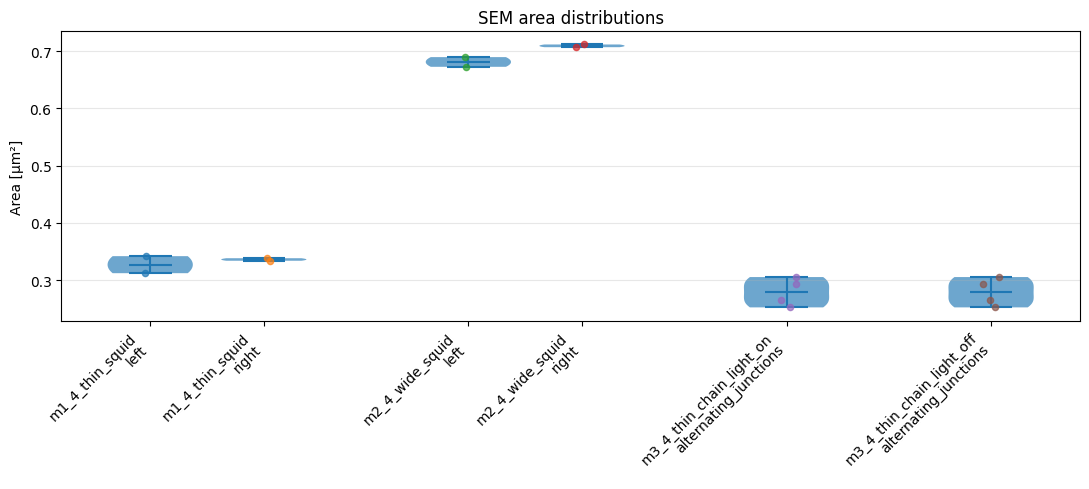

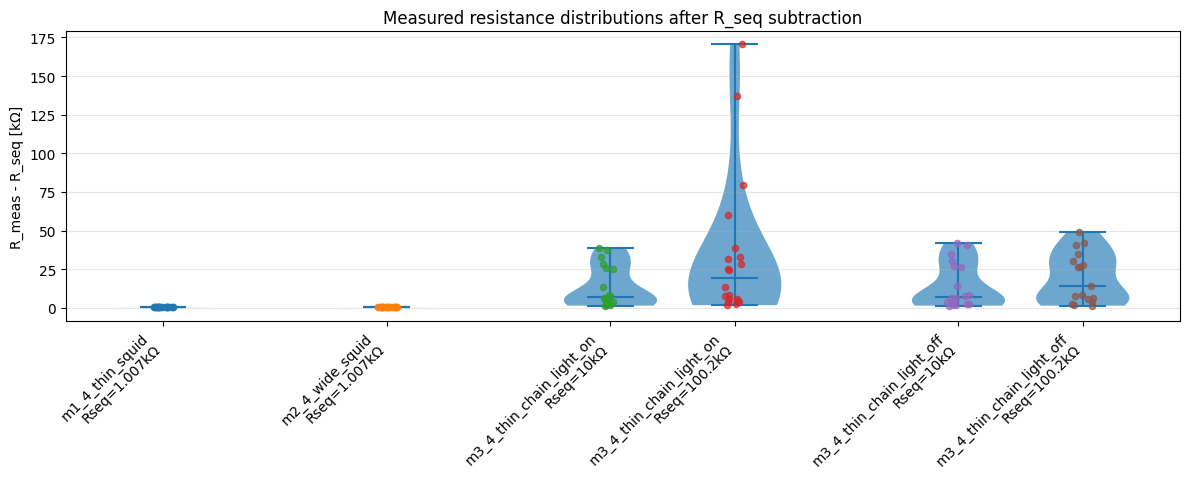

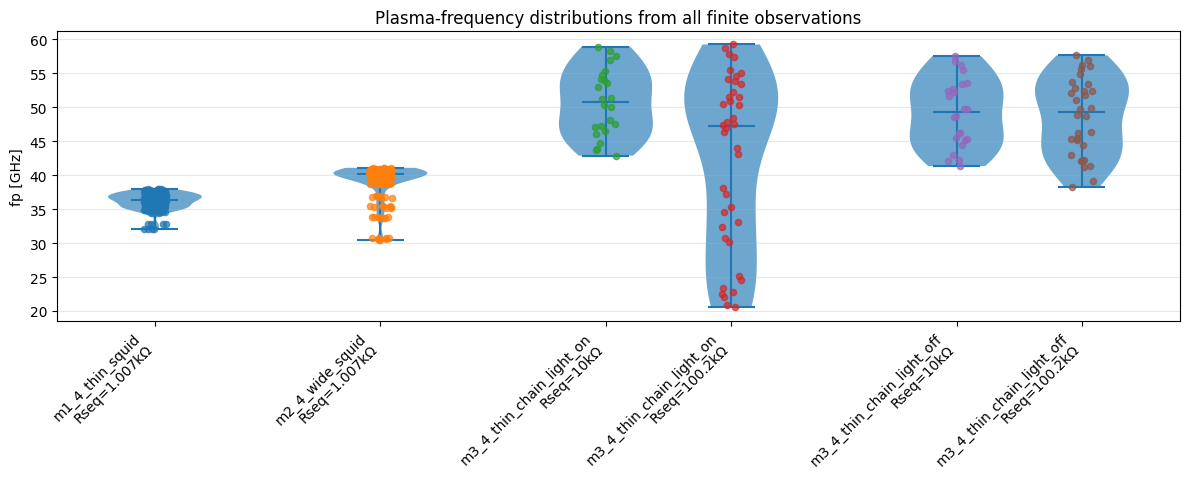

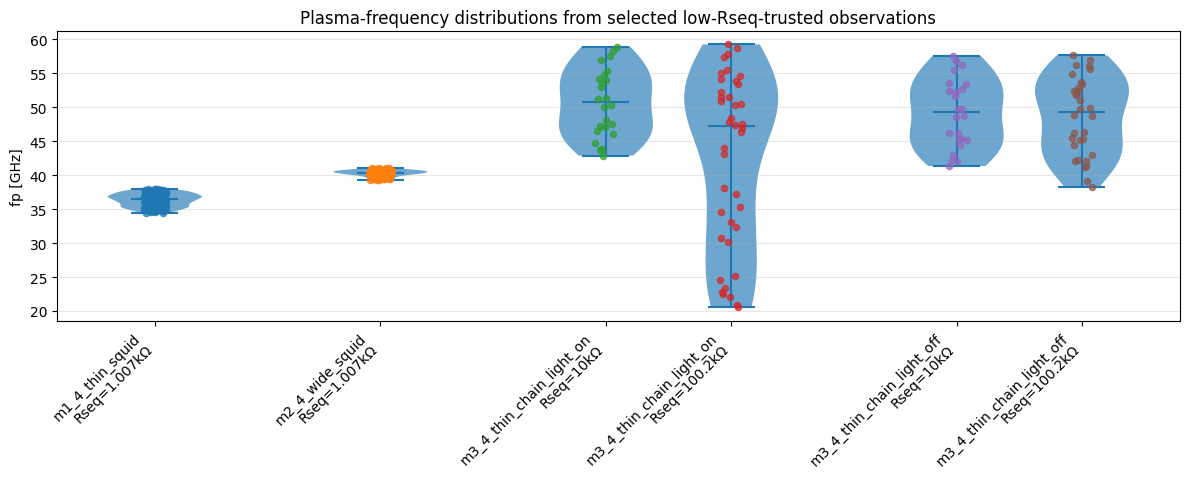

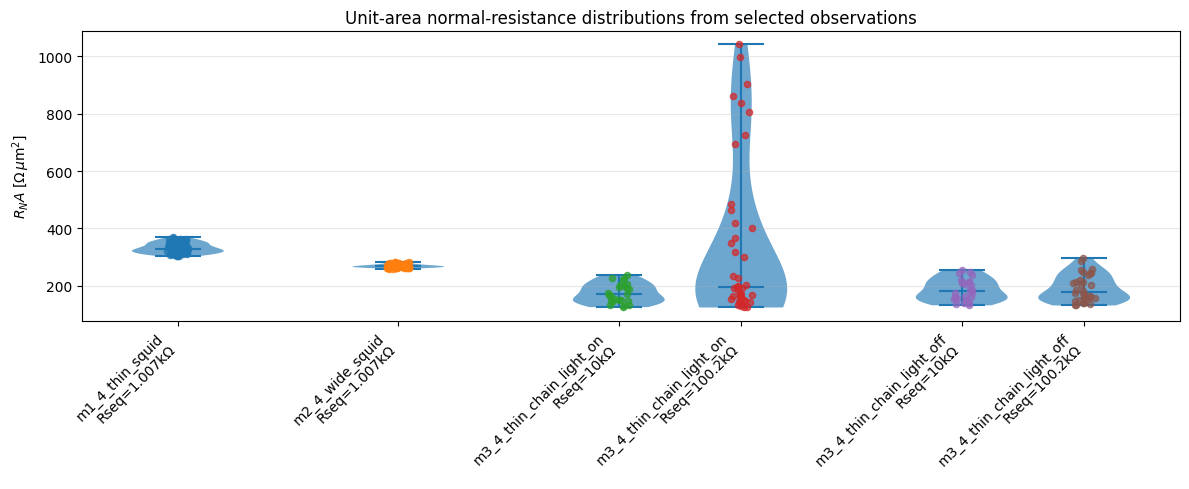

In [10]:
# ============================================================
# Violin-style distribution plots without seaborn
# ============================================================
def violin_by_groups(df, group_col, value_col, title, ylabel, subgroup_col=None, selected_col=None, figsize=(10, 4.8)):
    """
    If subgroup_col is None: one violin per group.
    If subgroup_col is given: one violin per (group, subgroup), spaced together.
    Overlays the actual data points with a small horizontal jitter.
    """
    if df.empty:
        print(f"No data for {title}")
        return

    data, labels, positions = [], [], []
    pos = 0
    groups = list(df[group_col].dropna().unique())
    for g in groups:
        gd = df[df[group_col] == g]
        if subgroup_col is None:
            vals = gd[value_col].dropna().to_numpy(float)
            if len(vals):
                data.append(vals); labels.append(str(g)); positions.append(pos); pos += 1
        else:
            subs = sorted(gd[subgroup_col].dropna().unique())
            for s in subs:
                vals = gd[gd[subgroup_col] == s][value_col].dropna().to_numpy(float)
                if len(vals):
                    data.append(vals)
                    if subgroup_col == "R_seq_ohm":
                        lab = f"{g}\nRseq={float(s)/1e3:g}kΩ"
                    else:
                        lab = f"{g}\n{s}"
                    labels.append(lab); positions.append(pos); pos += 1
            pos += 0.8

    if not data:
        print(f"No finite data for {title}")
        return

    plt.figure(figsize=figsize)
    vp = plt.violinplot(data, positions=positions, showmeans=False, showmedians=True, widths=0.75)
    for body in vp['bodies']:
        body.set_alpha(0.65)

    rng = np.random.default_rng(12345)
    for x0, vals in zip(positions, data):
        vals = np.asarray(vals, dtype=float)
        jitter = rng.uniform(-0.09, 0.09, size=len(vals)) if len(vals) > 1 else np.array([0.0])
        plt.scatter(np.full(len(vals), x0) + jitter, vals, s=20, alpha=0.7, zorder=3)

    plt.xticks(positions, labels, rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Area distributions: all SEM area observations.
area_df = sem_area_dataframe(TEST_STRUCTURES)
violin_by_groups(area_df, "structure", "area_um2", "SEM area distributions", "Area [µm²]", subgroup_col="population", figsize=(11, 5))

# R_meas distributions: finite net resistance after R_seq subtraction, separated by structure and R_seq.
r_frames = []
for name, meta in metas.items():
    df = meta["resistance_df"].copy()
    df["structure"] = name
    finite = df[(~df["is_OL"]) & np.isfinite(df["R_net_ohm"])]
    r_frames.append(finite)
r_all = pd.concat(r_frames, ignore_index=True) if r_frames else pd.DataFrame()
r_all["R_net_kOhm"] = r_all["R_net_ohm"] / 1e3
violin_by_groups(r_all, "structure", "R_net_kOhm", "Measured resistance distributions after R_seq subtraction", "R_meas - R_seq [kΩ]", subgroup_col="R_seq_ohm", figsize=(12, 5))

# Final wp/fp distributions: all observations × SEM samples, separated by structure and R_seq.
obs_fp_all = build_all_observation_fp(TEST_STRUCTURES, metas, selected_only=False)
violin_by_groups(obs_fp_all, "structure", "fp_GHz", "Plasma-frequency distributions from all finite observations", "fp [GHz]", subgroup_col="R_seq_ohm", figsize=(12, 5))

# Same but only selected/trusted observations.
obs_fp_sel = build_all_observation_fp(TEST_STRUCTURES, metas, selected_only=True)
violin_by_groups(obs_fp_sel, "structure", "fp_GHz", "Plasma-frequency distributions from selected low-Rseq-trusted observations", "fp [GHz]", subgroup_col="R_seq_ohm", figsize=(12, 5))


# ============================================================
# Unit-area normal resistance R_N A
# ============================================================
def build_unit_area_resistance(structures, metas, selected_only=True):
    """Build observation-level R_N*A values using the measured SEM junction areas."""
    rows = []

    for name, cfg in structures.items():
        meta = metas[name]
        rdf = meta["selected_df"] if selected_only else meta["resistance_df"]
        min_net = float(cfg.get("min_net_R_ohm", R_SELECTION["min_net_R_ohm"]))
        rdf = rdf[(~rdf["is_OL"]) & np.isfinite(rdf["R_net_ohm"]) & (rdf["R_net_ohm"] > min_net)]
        kind = cfg["kind"]

        if kind == "uniform_chain":
            N_j = int(cfg["junction_count"])
            pop = next(iter(cfg["sem"]))
            areas = sem_area_stats(cfg["sem"][pop], pop)["areas_um2"]
            for _, r in rdf.iterrows():
                Rn = r["R_net_ohm"] / N_j
                for sem_idx, area in enumerate(areas):
                    rows.append({
                        "structure": name,
                        "junction": pop,
                        "R_seq_ohm": r["R_seq_ohm"],
                        "site_id": r["site_id"],
                        "sem_idx": sem_idx,
                        "RnA_ohm_um2": Rn * area,
                    })

        elif kind == "asymmetric_squid":
            pops = list(cfg["sem"])
            A1s = sem_area_stats(cfg["sem"][pops[0]], pops[0])["areas_um2"]
            A2s = sem_area_stats(cfg["sem"][pops[1]], pops[1])["areas_um2"]
            # Two SQUID junctions are in parallel, so R_SQUID*(A1+A2)=R_N*A.
            for _, r in rdf.iterrows():
                for i, A1 in enumerate(A1s):
                    for j, A2 in enumerate(A2s):
                        rows.append({
                            "structure": name,
                            "junction": "SQUID equivalent",
                            "R_seq_ohm": r["R_seq_ohm"],
                            "site_id": r["site_id"],
                            "sem_idx": f"{i},{j}",
                            "RnA_ohm_um2": r["R_net_ohm"] * (A1 + A2),
                        })

        elif kind == "single_connected_squid":
            pop = cfg.get("connected_junction", next(iter(cfg["sem"])))
            areas = sem_area_stats(cfg["sem"][pop], pop)["areas_um2"]
            for _, r in rdf.iterrows():
                for sem_idx, area in enumerate(areas):
                    rows.append({
                        "structure": name,
                        "junction": pop,
                        "R_seq_ohm": r["R_seq_ohm"],
                        "site_id": r["site_id"],
                        "sem_idx": sem_idx,
                        "RnA_ohm_um2": r["R_net_ohm"] * area,
                    })

    return pd.DataFrame(rows)

unit_area_R = build_unit_area_resistance(TEST_STRUCTURES, metas, selected_only=True)
violin_by_groups(
    unit_area_R,
    "structure",
    "RnA_ohm_um2",
    "Unit-area normal-resistance distributions from selected observations",
    r"$R_N A$ [$\Omega\,\mu\mathrm{m}^2$]",
    subgroup_col="R_seq_ohm",
    figsize=(12, 5),
)


## 6. Old-style plots with both SEM-area and R-meas variance windows

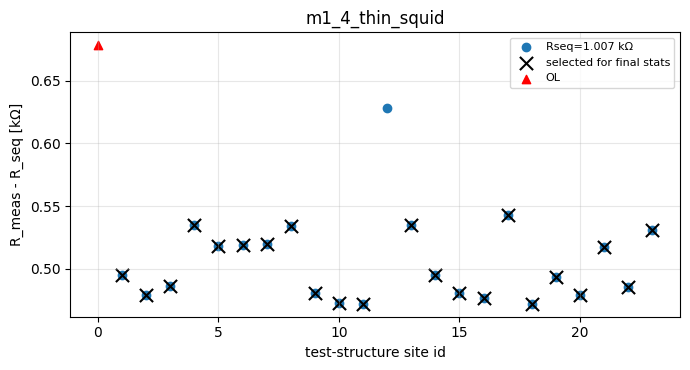

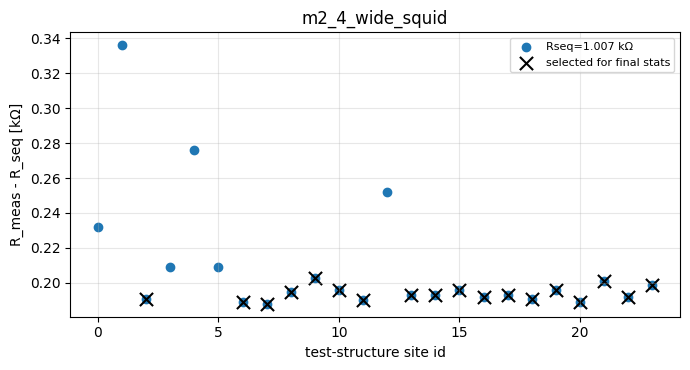

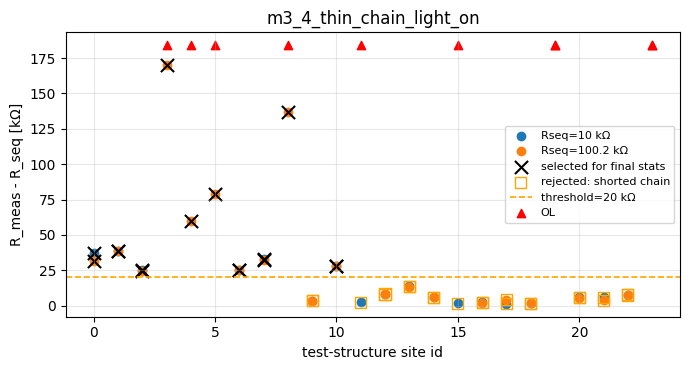

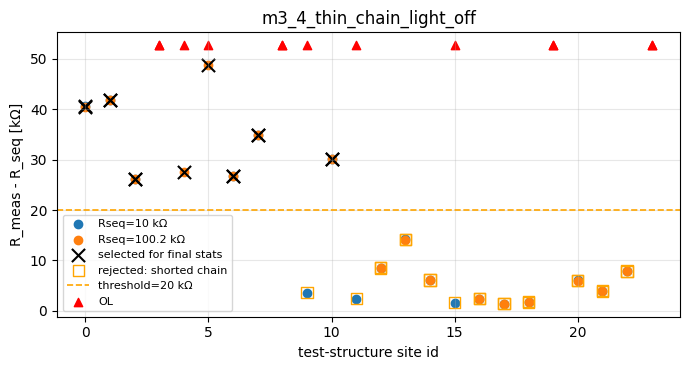

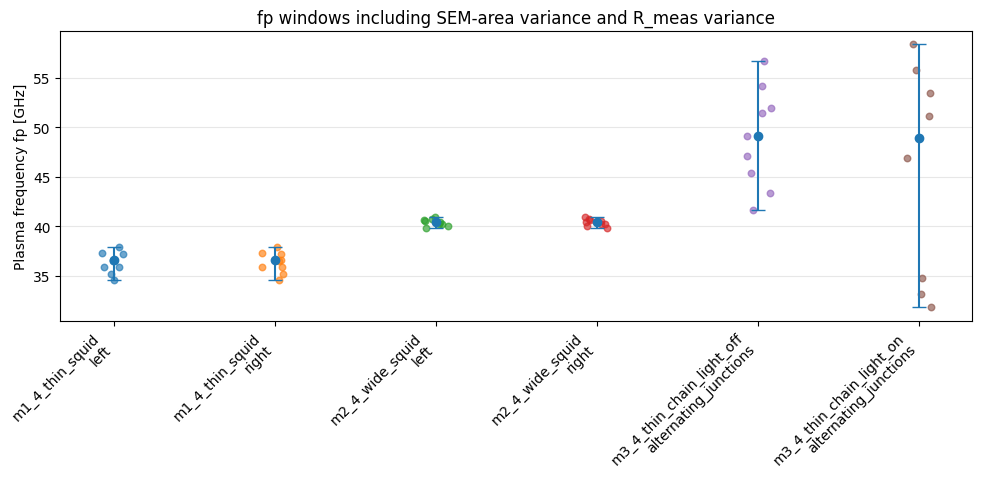

In [11]:
def plot_resistance_distribution(name: str, meta: Dict[str, Any]):
    df = meta["resistance_df"].copy()
    finite = df[(~df["is_OL"]) & np.isfinite(df["R_net_ohm"])]
    selected = meta["selected_df"]
    threshold = meta["resistance_summary"].get("min_net_R_threshold_ohm", np.nan)

    plt.figure(figsize=(7, 3.8))
    for rseq, g in finite.groupby("R_seq_ohm"):
        plt.scatter(g["site_id"], g["R_net_ohm"] / 1e3, label=f"Rseq={rseq/1e3:g} kΩ")
    if len(selected):
        plt.scatter(selected["site_id"], selected["R_net_ohm"] / 1e3, s=90, marker="x", color="black", label="selected for final stats")
    if np.isfinite(threshold):
        rejected = finite[finite["R_net_ohm"] <= threshold]
        if len(rejected):
            plt.scatter(rejected["site_id"], rejected["R_net_ohm"] / 1e3, s=65, marker="s", facecolors="none", edgecolors="orange", label="rejected: shorted chain")
        plt.axhline(threshold / 1e3, linestyle="--", linewidth=1.2, color="orange", label=f"threshold={threshold/1e3:g} kΩ")
    ol = df[df["is_OL"]]
    if len(ol):
        ymax = (finite["R_net_ohm"].max() / 1e3 * 1.08) if len(finite) else 1.0
        plt.scatter(ol["site_id"], np.full(len(ol), ymax), marker="^", color="red", label="OL")
    plt.title(name)
    plt.xlabel("test-structure site id")
    plt.ylabel("R_meas - R_seq [kΩ]")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

for name, meta in metas.items():
    plot_resistance_distribution(name, meta)


def plot_fp_windows_with_R_and_area(results: pd.DataFrame):
    """Error bars include both area window and selected R_meas window. Raw calculated fp points are overlaid."""
    if results.empty:
        print("No results to plot.")
        return
    plt.figure(figsize=(10, 5))
    labels, y, yerr_low, yerr_high = [], [], [], []
    raw_sets = []

    for (structure, junction), g in results.groupby(["structure", "junction"]):
        gm = g[(g["R_case"] == "R_median") & (g["area_case"] == "area_mean")]
        if gm.empty:
            continue
        f_mean = gm["fp_GHz"].iloc[0]
        vals = g["fp_GHz"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
        if vals.size == 0:
            continue
        labels.append(f"{structure}\n{junction}")
        y.append(f_mean)
        yerr_low.append(abs(f_mean - np.nanmin(vals)))
        yerr_high.append(abs(np.nanmax(vals) - f_mean))
        raw_sets.append(vals)

    x = np.arange(len(labels))
    plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt="o", capsize=5, zorder=4)

    rng = np.random.default_rng(54321)
    for x0, vals in zip(x, raw_sets):
        jitter = rng.uniform(-0.08, 0.08, size=len(vals)) if len(vals) > 1 else np.array([0.0])
        plt.scatter(np.full(len(vals), x0) + jitter, vals, s=22, alpha=0.65, zorder=3)

    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("Plasma frequency fp [GHz]")
    plt.title("fp windows including SEM-area variance and R_meas variance")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_fp_windows_with_R_and_area(results)


## 7. Selection and geometry notes

For **m1/4** and **m2/4**, the full 6×4 resistance tables are used with the robust SQUID resistance-selection procedure. Junction areas are calculated from the supplied SEM dimensions, separately for the physical right and left SQUID junctions.

For **m3/4**, the light-on and light-off datasets remain separate. First, the series resistance is subtracted point by point. A chain is then retained only when

\[
R_{\mathrm{chain,net}} = R_{\mathrm{meas}}-R_{\mathrm{seq}} > 20\,\mathrm{k}\Omega.
\]

This rejects the low-resistance shorted chains. All readable points above 20 kΩ are included, with no MAD/outlier rejection. The 50-junction chain resistance is divided by 50 to obtain the normal resistance per junction.

The thin-chain SEM population contains four measured alternating-island junction geometries. The large-chain SEM measurements are stored in `SEM_GEOMETRIES["large_chain"]` for reference, although m4/4 has no electrical dataset and is not analyzed.


## 8. Data-verification note

SEM dimensions entered in nanometres were converted to micrometres in the input cell. The supplied values are used directly without replacing them by the planned `0.260 µm` dimension. Explicit `OL`/unavailable resistance entries remain excluded from numerical calculations.
